# Classical Search Algorithms API

A guided tour of the shared machinery in `search_algorithms_utils.py`,
the pieces `search_algorithms.02.example.ipynb`'s minimax, alpha-beta, and
depth-limited search all build on:
- `SearchNode`: one node of a fully-materialized search tree
- `build_tree_graph()`: renders any `SearchNode` tree as a colored
  Graphviz diagram
- a widget that grows a real minimax tree one node at a time, instead of
  all at once, so the recursion in `_minimax()` becomes visible

The `Game` interface itself (`game.py`) and `TicTacToe` / `ConnectFour`
(`game_examples.py`) are covered in full in `game.01.API.ipynb`; see that
notebook first for the API these demos build on.

Parts 2-4 use `TicTacToe`, kept small so the tree diagrams stay readable.

Part 5 swaps in `ConnectThree` (i.e., `ConnectFour`'s gravity-drop rule on a
3x3, 3-in-a-row board) to show the same widget generalizes to a second
game without a bigger tree than `TicTacToe` already has.

See `README.md` for a description of every file in this directory.

## Imports

In [1]:
%load_ext autoreload
%autoreload 2

import logging

import helpers.hdbg as hdbg
import helpers.hnotebook as hnotebook

_LOG = logging.getLogger(__name__)

hdbg.init_logger(verbosity=logging.INFO)
hnotebook.config_notebook()

INFO  > /usr/local/lib/python3.12/site-packages/ipykernel_launcher.py -f /root/.local/share/jupyter/runtime/kernel-19056bcc-e097-4586-9eb6-6e98528f0224.json


In [2]:
import helpers.hintrospection as hintros
import research.Implement_MonteCarlo_Tree_Search_and_Alpha_Zero.game_examples as rimtsaazge
import research.Implement_MonteCarlo_Tree_Search_and_Alpha_Zero.search_algorithms_API_utils as rimtsaazsaau
import research.Implement_MonteCarlo_Tree_Search_and_Alpha_Zero.search_algorithms_utils as rimtsaazsau

try:
    from IPython.display import display
except ImportError:
    display = print  # type: ignore

# Part 1: Library Overview

## What problem does `search_algorithms_utils.py` solve?

- Search an AND-OR game tree exactly (minimax, alpha-beta pruning) or
approximately (depth-limited search), and materialize the tree each algorithm
actually visits so it can be inspected and drawn, not just the single move it
returns
- Stay game-agnostic: every algorithm only calls the `Game` methods, so a new
game plugs in without touching `search_algorithms_utils.py`

## Mental model

| Object | Description | Type / Comments |
|--------|-------------|------------------|
| `Game` | Game-rules interface | see `game.01.API.ipynb` |
| `SearchNode` | One tree node | tracks `state`, `children`, `value`, `pruned`, `is_heuristic` |
| `build_minimax_tree(game, state)` | Exact search | returns the fully-built root `SearchNode` |
| `build_alpha_beta_tree(game, state)` | Exact search, fewer nodes | same shape, some children `.pruned` |
| `build_depth_limited_tree(game, state, evaluate_fn)` | Approximate search | cuts at `DEFAULT_MAX_DEPTH`, `.is_heuristic` at the cut |
| `pick_best_move(game, root)` | Read the answer off a tree | `.move` of the best-valued root child |
| `build_tree_graph(root)` | Visualize a tree | Graphviz diagram, `DEFAULT_RENDER_DEPTH` levels by default |

## Cell 1.1: Construct the game to search

In [3]:
game = rimtsaazge.TicTacToe()
demo_state = (1, 1, 0, -1, -1, 0, 0, 0, 0)
print("demo_state:")
print(game.render(demo_state))

demo_state:
X X .
O O .
. . .

fork_state:
X O .
. . .
. . .


In [ ]:
fork_state = (1, -1, 0, 0, 0, 0, 0, 0, 0)
print("fork_state:")
print(game.render(fork_state))

# Part 2: `SearchNode`

**Mental model**:
- each `SearchNode` wraps one `State` plus the backed-up `.value` a
  search algorithm computed for it
- unlike `mcts_utils.MCTSNode`, which grows one node per simulation and
  keeps a running `visit_count` / `value_sum`, a `SearchNode` tree is
  visited once, in a single recursive pass, and each node's `.value` is
  final as soon as it is set

## Cell 2.1: Construct a node directly

In [4]:
hintros.print_obj_info(rimtsaazsau.SearchNode)

**SearchNode**
- `add_child(self, move: int, state: Tuple[int, ...]) -> 'SearchNode'`: Append and return a new child of `move` -> `state`.

https://github.com/gpsaggese/gpsaggese.github.io/blob/gp/research/Implement_MonteCarlo_Tree_Search_and_Alpha_Zero/search_algorithms_utils.py#L92


In [15]:
root = rimtsaazsau.SearchNode(demo_state)
print(f"Type: {type(root)}")
print("state:", root.state)
print("value (nothing computed yet):", root.value)
print("children:", root.children)
print("pruned:", root.pruned)
print(" is_heuristic:", root.is_heuristic)

Type: <class 'research.Implement_MonteCarlo_Tree_Search_and_Alpha_Zero.search_algorithms_utils.SearchNode'>
state: (1, 1, 0, -1, -1, 0, 0, 0, 0)
value (nothing computed yet): None
children: []
pruned: False
 is_heuristic: False


## Cell 2.2: Growing a tree by hand with `add_child()`

A real search algorithm
- calls `add_child()` once per legal move
- then assigns `.value` once that child's own subtree is done

Here we do the same thing by hand, for the single move "play cell 2 and win".

In [17]:
print("demo_state:")
print(game.render(demo_state))

demo_state:
X X .
O O .
. . .


In [18]:
winning_state = game.apply_move(demo_state, 2)
print("winning_state:")
print(game.render(winning_state))

child = root.add_child(move=2, state=winning_state)
child.value = float(game.get_winner(winning_state))
root.value = child.value
print(root)
print(child)

winning_state:
X X X
O O .
. . .
SearchNode(move=None, value=1.00, children=2, pruned=False)
SearchNode(move=2, value=1.00, children=0, pruned=False)


## Cell 2.3: `node_count` and `num_explored_nodes`

- Both properties recurse over `.children`
- They only disagree once some node is `.pruned` (alpha-beta), which excludes it
  (and everything under it) from `num_explored_nodes` but not from `node_count`.

In [19]:
print("node_count (root + 1 child):", root.node_count)
print("num_explored_nodes (nothing pruned yet):", root.num_explored_nodes)

node_count (root + 1 child): 3
num_explored_nodes (nothing pruned yet): 3


In [20]:
pruned_child = root.add_child(move=5, state=game.apply_move(demo_state, 5))
pruned_child.pruned = True
print("node_count (root + 2 children):", root.node_count)
print(
    "num_explored_nodes (the pruned child no longer counts):",
    root.num_explored_nodes,
)

node_count (root + 2 children): 4
num_explored_nodes (the pruned child no longer counts): 3


**Key observations**:
- `SearchNode` itself never runs a search
    - `build_minimax_tree()`, `build_alpha_beta_tree()`, and
    `build_depth_limited_tree()` are the functions that call `add_child()` / set
    `.value` on our behalf
- `pruned` and `is_heuristic` are the two flags that distinguish an
  *exact* backed-up value from a value that is missing (pruned) or only
  approximate (a depth-limited cut)

# Part 3: `build_tree_graph()`: coloring a search tree

**Mental model**: `build_tree_graph()`
- Reads only 5 fields off each node (`.value`, `.move`, `.pruned`, `.is_heuristic`, `.children`)
- Turns them into one of 4 colors
- Never re-runs a search, so any tree assembled by hand, like the one below,
renders exactly like a real one.

## Cell 3.1: A hand-built tree covering every color

One root with 3 children, each one demonstrating a different way a node
can end up:
- An ordinary internal node
- An exact terminal leaf
- A depth-limited cut
- A node alpha-beta pruned before ever exploring it.

In [21]:
fake_root = rimtsaazsau.SearchNode(demo_state)
fake_root.value = 0.5

# Blue: an ordinary internal node, with one exact terminal leaf (green).
internal_state = game.apply_move(demo_state, 5)
internal_child = fake_root.add_child(move=5, state=internal_state)
internal_child.value = 1.0
terminal_grandchild = internal_child.add_child(
    move=6, state=game.apply_move(internal_state, 6)
)
terminal_grandchild.value = 1.0

# Amber: a depth-limited cut, scored by a heuristic instead of backed up.
heuristic_child = fake_root.add_child(move=7, state=game.apply_move(demo_state, 7))
heuristic_child.value = -0.2
heuristic_child.is_heuristic = True

# Grey, dashed: alpha-beta recorded this move but never explored it.
pruned_leaf = fake_root.add_child(move=8, state=game.apply_move(demo_state, 8))
pruned_leaf.pruned = True

## Cell 3.2: Rendering it, and reading the legend

**Goal**:
- See each of the 4 colors `build_tree_graph()` can draw in a single,
  small diagram, next to the field that decided it

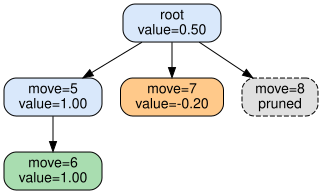

In [22]:
display(rimtsaazsau.build_tree_graph(fake_root, max_depth=2))

**Key observations**:

- Nodes
    - blue (`internal_child`): has children and an exact `.value` -- an
      ordinary explored internal node
    - green (`terminal_grandchild`): an exact `.value` and no children --
      a terminal state, `get_winner()`'s outcome
    - amber (`heuristic_child`): `.is_heuristic = True` -- a depth-limited
      cut, `.value` is a heuristic estimate, not an exact outcome
    - grey, dashed (`pruned_leaf`): `.pruned = True` -- alpha-beta recorded
      the move but never explored it, so it has no `.value` and no children
- `build_tree_graph()` checks `.pruned` first, then `.is_heuristic`,
  then whether `.children` is empty (see the order in
  `search_algorithms_utils._node_style()`)
- `max_depth` (here `2`) caps how many levels below the root render
  before an "... N more" placeholder takes over; `DEFAULT_RENDER_DEPTH`
  is the value used when a caller does not override it

# Part 4: Building the minimax tree step by step

**Mental model**: `build_minimax_tree()` calls a private recursive
`_minimax()` that
- (1) creates a child via `add_child()`
- (2) recurses into it, and only after its entire subtree is done
- (3) backs up its `.value`, then moves to the next sibling.

- The widget below replays that exact order, one event at a time, on the *real*
tree `build_minimax_tree()` builds, instead of running a separate copy of the
algorithm.

## Cell 4.1: `demo_state` and `fork_state`, side by side

- `demo_state` has an immediate winning move
- `fork_state` needs looking 3 plies ahead to see the forced win

Switching between them below switches which tree is being grown.

In [11]:
print("demo_state:")
print(game.render(demo_state))
print("\nfork_state:")
print(game.render(fork_state))

demo_state:
X X .
O O .
. . .

fork_state:
X O .
. . .
. . .


## Cell 4.2: The step-by-step widget

**Goal**:
- Watch `SearchNode`s appear (grey, pending) in the same order
  `_minimax()` creates them, then turn green/blue (`value` backed up) in
  the same order it returns from each recursive call
- See that the bottom of a subtree finishes (and turns green) before its
  parent gets a value, and a parent before *its* parent: recursion made
  visible, one event at a time

**Parameters**:
- `state`: switch between `demo_state` and `fork_state`
- `step`: how many of the (node created / value backed up) events to
  replay so far

In [12]:
rimtsaazsaau.cell4_2_build_minimax_step_widget(
    game, {"demo_state": demo_state, "fork_state": fork_state}
)

**Key observations**:
- Every node is grey the instant it is created, since its own value
  depends on children not explored yet
- A leaf (no children, per the real, fully-built tree) turns green as
  soon as it is created and immediately valued -- `game.is_terminal()`
  already decided its `.value`, there is nothing further to explore
- The last event always backs up the root's own value: at that step the
  "Done" line reports the same `root.value` and best move
  `search_algorithms.02.example.ipynb` Part 3 finds via
  `build_minimax_tree()` directly

# Part 5: A second game: Connect Three

**Mental model**: none of Parts 2-4 mentioned `TicTacToe` by name; the
same `SearchNode`, `build_minimax_tree()`, and step-by-step widget work
unchanged against `ConnectThree`. What changes is only the board and the
move rule (a column drop instead of a free cell choice) -- `ConnectFour`
itself is not used here since its full game tree is far too large to
grow node by node in a widget.

## Cell 5.1: A tactical position on a 3x3 gravity board

In [23]:
connect_three = rimtsaazge.ConnectThree()
ct_demo_state = (0, 0, 0, 1, 0, -1, 1, 0, -1)
print(connect_three.render(ct_demo_state))
print("legal moves:", connect_three.get_legal_moves(ct_demo_state))

. . .
X . O
X . O
legal moves: [0, 1, 2]


X has two discs stacked in column 0; dropping a third one there completes
a vertical three-in-a-row and wins immediately -- the gravity-drop
equivalent of `demo_state` above.

## Cell 5.2: The same widget, a different game

In [24]:
rimtsaazsaau.cell5_1_build_connect_three_step_widget(connect_three, ct_demo_state)